##  House Prices Regression

In [104]:
# Loading the data 
import pandas as pd
import numpy as np

# Load data
df = pd.read_csv("house_price_prediction_dataset.csv")

# Basic info
df.shape
df.head()
df.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

Initial feature classification based on data types showed 43 categorical and 38 numerical variables. However, certain features like MSSubClass, although stored as integers, represent categorical information and were converted accordingly. Additionally, identifier columns such as Id were removed as they do not contribute to prediction.

In [105]:
#remove id
df.drop('Id', axis=1, inplace=True)

In [106]:


#fix hte colum nature
df['MSSubClass'] = df['MSSubClass'].astype(str)

cat_cols = df.select_dtypes(include=['object']).columns
num_cols = df.select_dtypes(exclude=['object']).columns

print("Categorical:", len(cat_cols))
print("Numerical:", len(num_cols))

Categorical: 44
Numerical: 36


Some numeric-looking columns are actually categorical:

Example:

MSSubClass → should be categorical

Features were divided into categorical and numerical types based on data types. Some numerical-looking variables like MSSubClass were converted to categorical as they represent classes rather than continuous values.

In [107]:
# Target variable
df['SalePrice'].describe()

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

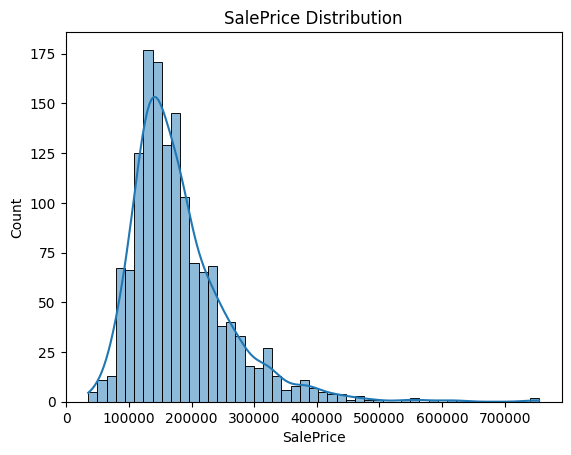

In [108]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(df['SalePrice'], kde=True)
plt.title("SalePrice Distribution")
plt.show()

SalePrice is right-skewed
Few houses have very high prices (outliers)
Models like Linear Regression work better with normal distribution

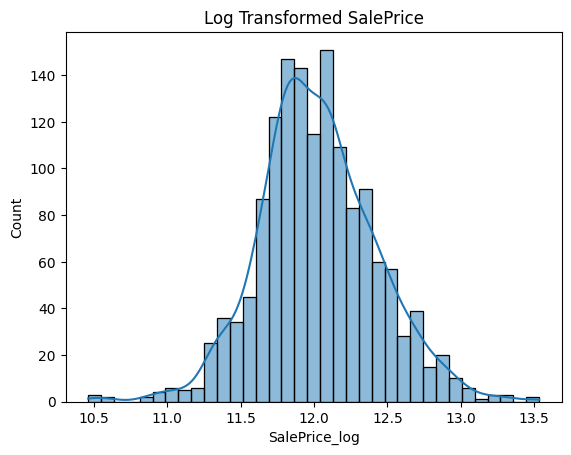

In [109]:
df['SalePrice_log'] = np.log1p(df['SalePrice'])

sns.histplot(df['SalePrice_log'], kde=True)
plt.title("Log Transformed SalePrice")
plt.show()

Mising Value Analysis

In [110]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

missing_percent = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_percent
})

missing_df.head(20)

,Missing Count,Missing %
PoolQC,1453,99.520548
MiscFeature,1406,96.301370
Alley,1369,93.767123
Fence,1179,80.753425
MasVnrType,872,59.726027
FireplaceQu,690,47.260274
LotFrontage,259,17.739726
GarageType,81,5.547945
GarageYrBlt,81,5.547945
GarageFinish,81,5.547945


In [111]:
#column were none is as value
none_cols = [
    'PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu',
    'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
    'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2'
]
for col in none_cols:
    df[col] = df[col].fillna('None')

# imputing numerical colum with median
df['LotFrontage'] = df['LotFrontage'].fillna(df['LotFrontage'].median())

garage_num_cols = ['GarageYrBlt', 'GarageArea', 'GarageCars']

#Garage column
for col in garage_num_cols:
    df[col] = df[col].fillna(0)


bsmt_num_cols = ['BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF',
                 'TotalBsmtSF', 'BsmtFullBath', 'BsmtHalfBath']

for col in bsmt_num_cols:
    df[col] = df[col].fillna(0)

mode_cols = ['MSZoning', 'Electrical', 'KitchenQual', 'Exterior1st', 'Exterior2nd', 'SaleType']

for col in mode_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [112]:
#check if  all missing values handelled
df.isnull().sum().sum() 

np.int64(880)

In [113]:
# check waht is remaining in missing data analysis
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

missing

MasVnrType    872
MasVnrArea      8
dtype: int64

The MasVnrType feature represents the type of masonry veneer used in the house. Missing values in this column were interpreted as the absence of veneer and were imputed with "None". The corresponding numerical feature MasVnrArea was filled with 0 to maintain consistency, indicating no veneer area.

In [119]:
df['MasVnrType'] = df['MasVnrType'].fillna('None')
df['MasVnrArea'] = df['MasVnrArea'].fillna(0)
#validate everything fixed
df.isnull().sum().sum() 

np.int64(0)

In [120]:
#lets seperate feature and target
X = df.drop('SalePrice', axis=1)
y = df['SalePrice']

In [121]:
#identify column types after cleaning
cat_cols = X.select_dtypes(include=['object']).columns
num_cols = X.select_dtypes(exclude=['object']).columns

print("Categorical:", len(cat_cols))
print("Numerical:", len(num_cols))

Categorical: 44
Numerical: 36


Encoding Based on Your Data Dictionary:

In [122]:
#quality-Based Features
quality_map = {
    'None': 0,
    'Po': 1,
    'Fa': 2,
    'TA': 3,
    'Gd': 4,
    'Ex': 5
}
qual_cols = [
    'ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond',
    'HeatingQC', 'KitchenQual', 'FireplaceQu',
    'GarageQual', 'GarageCond', 'PoolQC'
]

for col in qual_cols:
    df[col] = df[col].map(quality_map)

#Basement Exposure
bsmt_exposure_map = {
    'None': 0, 'No': 1, 'Mn': 2, 'Av': 3, 'Gd': 4
}

df['BsmtExposure'] = df['BsmtExposure'].map(bsmt_exposure_map)

#Basement Finish Type
bsmt_fin_map = {
    'None': 0, 'Unf': 1, 'LwQ': 2, 'Rec': 3,
    'BLQ': 4, 'ALQ': 5, 'GLQ': 6
}

df['BsmtFinType1'] = df['BsmtFinType1'].map(bsmt_fin_map)
df['BsmtFinType2'] = df['BsmtFinType2'].map(bsmt_fin_map)

#Garage Finish
garage_finish_map = {
    'None': 0, 'Unf': 1, 'RFn': 2, 'Fin': 3
}

df['GarageFinish'] = df['GarageFinish'].map(garage_finish_map)

#Functional
functional_map = {
    'Sal': 1, 'Sev': 2, 'Maj2': 3, 'Maj1': 4,
    'Mod': 5, 'Min2': 6, 'Min1': 7, 'Typ': 8
}

df['Functional'] = df['Functional'].map(functional_map)

NOMINAL FEATURES --> one hot encoded

In [123]:
cat_cols = df.select_dtypes(include=['object']).columns

df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

Features like PoolQC, Alley, and Fence were filled with "None" to indicate absence

Numerical features such as LotFrontage were imputed using the median

Garage and basement-related numerical features were filled with 0, indicating no such facility

Remaining categorical features were imputed using the mode

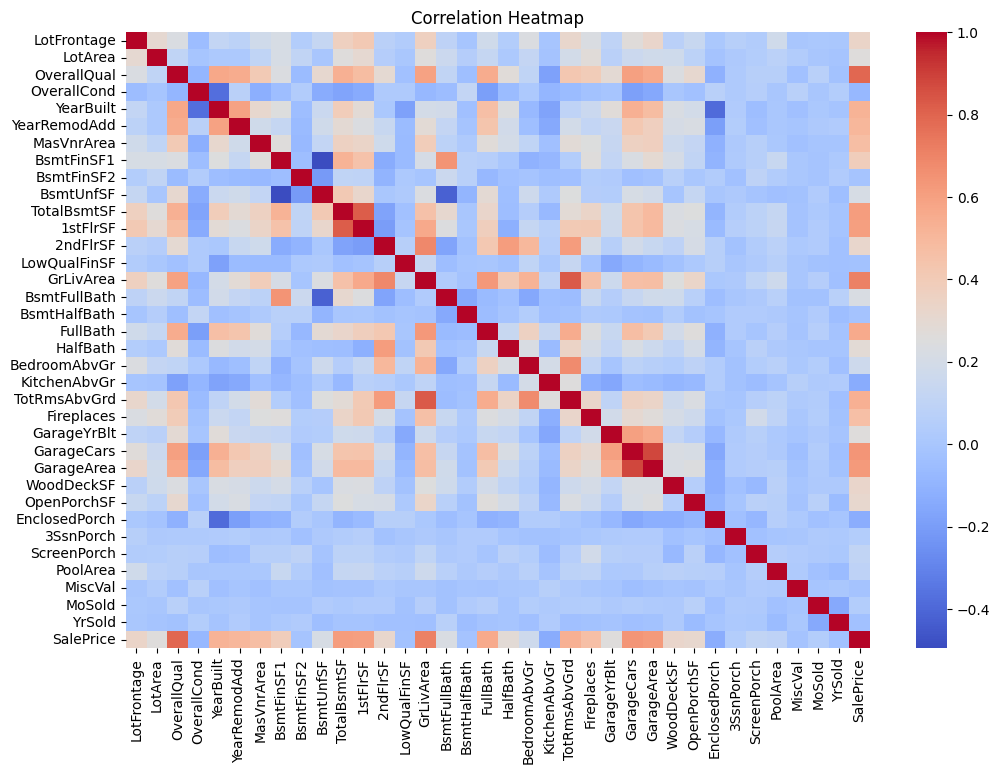

In [115]:
# Corelation and Heatmaps

plt.figure(figsize=(12,8))
corr = df[num_cols].corr()

sns.heatmap(corr, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [116]:
#target corelation
corr_target = corr['SalePrice'].sort_values(ascending=False)
corr_target.head(10)

SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
Name: SalePrice, dtype: float64

Features like OverallQual, GrLivArea, and GarageCars show strong positive correlation with SalePrice, indicating that larger and higher-quality houses tend to have higher prices.

Bivariate anlysis

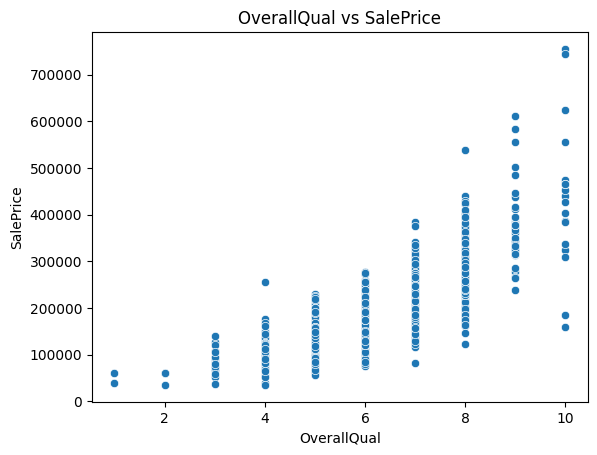

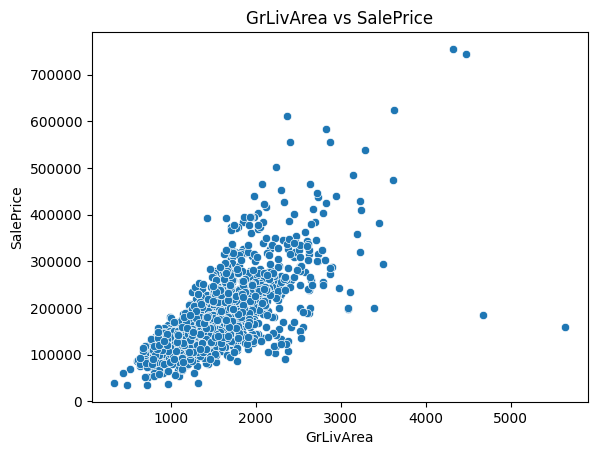

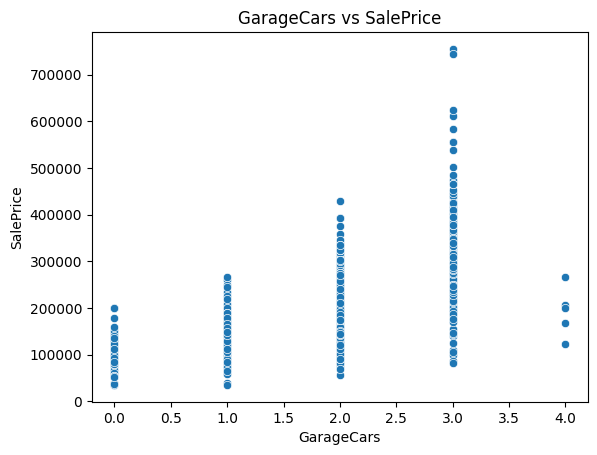

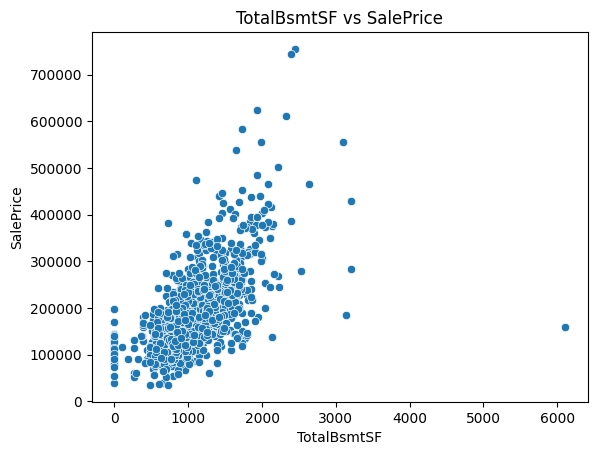

In [117]:
top_features = ['OverallQual', 'GrLivArea', 'GarageCars', 'TotalBsmtSF']

for col in top_features:
    sns.scatterplot(x=df[col], y=df['SalePrice'])
    plt.title(f"{col} vs SalePrice")
    plt.show()

GrLivArea → strong linear relationship

OverallQual → clear upward trend

Outliers present (very large area but low price)


Scatterplots reveal strong linear relationships between key features and SalePrice. However, some outliers are observed, particularly in GrLivArea, which may need treatment

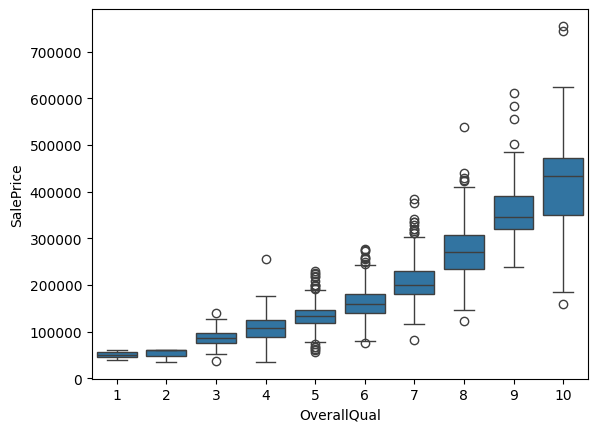

In [118]:
#Box plots for catgorical 
sns.boxplot(x='OverallQual', y='SalePrice', data=df)
plt.show()